## Notebook contents: logistic regression, RFLR, HMM, FQ-learning models fit to 2ABT data
This notebook provides an overview of fitting and predicting mouse behavior in a two-armed bandit using descriptive, algorithmic, and theoretical models.


In [52]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import pyarrow.feather as feather

import plot_models_v_mouse as bp
import model_policies as models
from sklearn.model_selection import train_test_split
import conditional_probs as cprobs
import resample_and_model_reps as reps
import model_fitting as fit

In [74]:
def calculate_target(row):
    """Calculates the 'Target' array for a session."""
    choices = np.array(row['choiceArray'])
    rewards = np.array(row['rewardArray'])
    if choices.size == 0:
        return []
    targets = np.where(rewards == 1, choices, 1 - choices)
    return targets.tolist()

# ---- THIS FUNCTION IS CORRECTED AND MORE ROBUST ----
def calculate_block_trial(row):
    """Calculates the trial number within each block."""
    block_type = row['blockTypeArray']
    if not isinstance(block_type, (list, np.ndarray)) or len(block_type) == 0:
        return []
    
    block_trials = []
    # If the list is not empty, the first trial is always 1
    block_trials.append(1) 
    
    # Iterate from the second trial to the end
    for i in range(1, len(block_type)):
        # If the block type is the same as the previous trial, increment counter
        if block_type[i] == block_type[i-1]:
            block_trials.append(block_trials[i-1] + 1)
        # Otherwise, reset the counter to 1 for the new block
        else:
            block_trials.append(1)
            
    return block_trials

def calculate_switch(row):
    """Calculates the 'Switch' array for a session."""
    choice_array = np.array(row['choiceArray'])
    if choice_array.size == 0:
        return []
    
    switches = np.zeros_like(choice_array, dtype=float)
    switches[1:] = np.where(choice_array[1:] != choice_array[:-1], 1, 0)
    return switches.tolist()

# Load in data and train-test-split

In [61]:
data_sample = pd.read_csv(os.path.join('bandit_data.csv'))
data_sample.head()

,Trial,blockTrial,Decision,Switch,Reward,Condition,Target,blockLength,Session,Mouse
0,11.0,11.0,1.0,0.0,1.0,90-10,1.0,58.0,m1_77,m1
1,12.0,12.0,1.0,0.0,1.0,90-10,1.0,58.0,m1_77,m1
2,13.0,13.0,1.0,0.0,1.0,90-10,1.0,58.0,m1_77,m1
3,14.0,14.0,1.0,0.0,1.0,90-10,1.0,58.0,m1_77,m1
4,15.0,15.0,1.0,0.0,1.0,90-10,1.0,58.0,m1_77,m1


In [96]:
data_mine = pd.read_feather('dataChoiceRew')
data_mine = data_mine.drop(columns=['win_switch_trials', 'lose_stay_trials', 'win_stay_trials', 'lose_switch_trials', 'total_wins', 'total_losses', 'sensor', 'siglocs', 'expgrp', 'implant'])
data_mine = data_mine[(data_mine['total_trials'] <= 1000) & (data_mine['sesType'] != 'FR1')] 
data_mine['date'] = data_mine['date'].astype('float').astype('int').astype('str')
data_mine['Session'] = data_mine['mouse'] + '_' + data_mine['date']
data_mine = data_mine.drop(columns=['date', 'total_trials'])
data_mine = data_mine.rename(columns={'sesType' : 'Condition'})
data_mine.head()

,Condition,sesDay,choiceArray,rewardArray,blockTypeArray,mouse,sex,group,Session
0,75_25,3,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",262_614,M,control,262_614_240408
1,100_0,5,"[0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",670_19504,M,control,670_19504_241115
2,75_25,4,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",663_19351,F,asyn,663_19351_241220
5,90_10,5,"[0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",264_615,F,control,264_615_240321
6,75_25,4,"[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",663_19353,F,asyn,663_19353_241213


In [97]:
data_mine['targetArray'] = data_mine.apply(calculate_target, axis=1)
data_mine['blockTrialArray'] = data_mine.apply(calculate_block_trial, axis=1)
data_mine['switchArray'] = data_mine.apply(calculate_switch, axis=1)
data_mine = data_mine.rename(columns={
    'choiceArray': 'Decision',
    'rewardArray': 'Reward'
})

cols_to_explode = [
    'Decision', 
    'Reward', 
    'targetArray', 
    'blockTrialArray', 
    'switchArray'
]


cols_to_check = [
    'Decision', 
    'Reward', 
    'targetArray', 
    'blockTrialArray', 
    'switchArray'
]


In [98]:
# 3. Explode the DataFrame to create one row per trial
data_long = data_mine.explode(cols_to_explode).reset_index(drop=True)

# 4. Rename the newly created columns to their final names
data_long = data_long.rename(columns={
    'targetArray': 'Target',
    'blockTrialArray': 'blockTrial',
    'switchArray': 'Switch'
})



Starting diagnostic check...

✅ Diagnostic complete. No mismatches found.
This is unexpected. The error might be more subtle.


In [99]:
probs='100_0' # P(high)-P(low)
seq_nback=3 # history length for conditional probabilites
train_prop=0.7 # for splitting sessions into train and test
seed = np.random.randint(1000) # set seed for reproducibility

data = data_mine.loc[data_mine.Condition==probs] # segment out task condition

In [101]:
data = cprobs.add_history_cols(data, seq_nback) # set history labels up front

train_session_ids, test_session_ids = train_test_split(data.Session.unique(), 
                                                       train_size=train_prop, random_state=seed) # split full df for train/test

data['block_pos_rev'] = data['blockTrial'] - data['blockLength'] # reverse block position from transition
data['model']='mouse'
data['highPort'] = data['Decision']==data['Target'] # boolean, chose higher probability port

train_features, _, _ = reps.pull_sample_dataset(train_session_ids, data)
test_features, _, block_pos_core = reps.pull_sample_dataset(test_session_ids, data)

bpos_mouse = bp.get_block_position_summaries(block_pos_core)
bpos_mouse['condition'] = 'mouse'

c:\Users\jan7154\Documents\GitHub\2ABT_behavior_models\conditional_probs.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['decision_seq']=np.nan # initialize column for decision history (current trial excluded)
c:\Users\jan7154\Documents\GitHub\2ABT_behavior_models\conditional_probs.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['reward_seq']=np.nan # initialize column for laser stim history (current trial excluded)


ValueError: setting an array element with a sequence.

# Plot conditional switch probabilities for just the mouse behavior first
Sort held out conditioned history sequences by full dataset P(switch|sequence)

In [11]:
# full dataset for sorting
df_mouse_symm_reference = cprobs.calc_conditional_probs(data, symm=True, 
                                                        action=['Switch']).sort_values('pswitch')

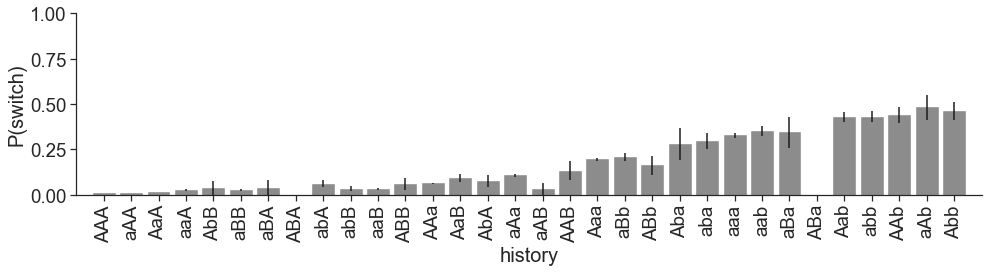

In [12]:
df_mouse_symm = cprobs.calc_conditional_probs(block_pos_core, symm=True, action=['Switch', 'Decision'])
df_mouse_symm = cprobs.sort_cprobs(df_mouse_symm, df_mouse_symm_reference.history.values)
bp.plot_sequences(df_mouse_symm, alpha=0.5) 

# Fit models on training data, predict choice probabilities for held-out data
Model predictions (`model_probs`) for each held out session stored for plotting below.

## Logistic regression
Fit logistic regression on training set, with coefficients for choice history (up to trial n-L1), choice-reward interaction (up to trial n-L2), and reward history (up to trial n-L3).

In [13]:
L1 = 1 # choice history
L2 =  5 # choice * reward history
L3 = 0
memories = [L1, L3, L2, 1]

lr = models.fit_logreg_policy(train_features, memories) # refit model with reduced histories, training set
model_probs = models.compute_logreg_probs(test_features, lr_args=[lr, memories])

## Recursively formulated logistic regression (RFLR)

In [15]:
params, nll = fit.fit_with_scipy(fit.log_probability_rflr, train_features) # quick fit on RFLR parameters
alpha, beta, tau = params
print(f'alpha = {alpha[0]:.2f}')
print(f'beta = {beta[0]:.2f}')
print(f'tau = {tau[0]:.2f}')

model_probs = models.RFLR(test_features, params)

IndexError: invalid index to scalar variable.

## Hidden Markov model (HMM)

In [ ]:
q = 0.98 # 1-p(block transition)
p = 0.8 # p(reward | high port)

model_probs = models.compute_hmm_probs(test_features, parameters={'q':q, 'p':p})

## forgetting Q-learning model (F-Q model)
Using $\alpha$, $\beta$, and $\tau$ parameters derived from fit RFLR above.

In [ ]:
T = (1-np.exp(-1/tau))/beta 
k = 1-np.exp(-1/tau) 
a = alpha 

model_probs = models.fq_learning_model(test_features, parameters=[a, k, T])

# Predict action and plot
Apply policy ('greedy', 'stochastic', or 'softmax') to select actions from `model_probs` and plot behavior. Can add replicate runs for stochastic policies.

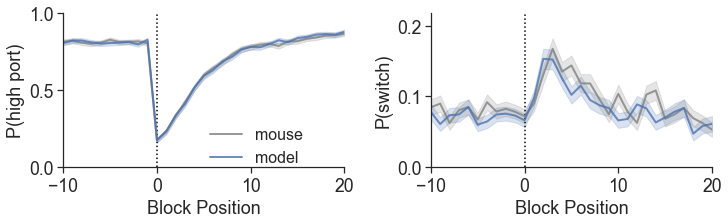

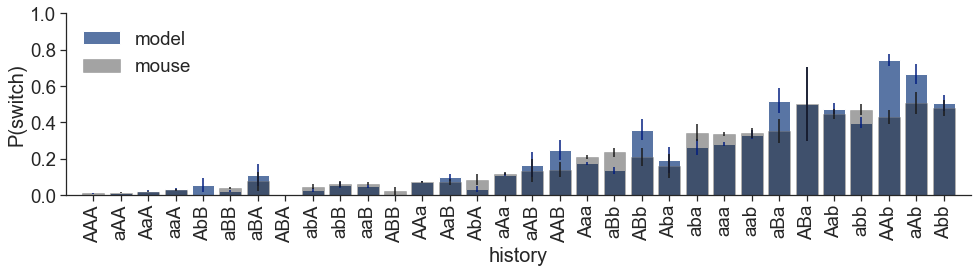

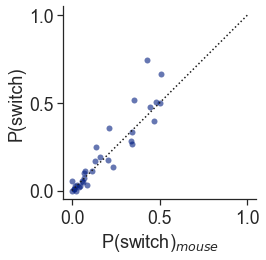

In [ ]:
model_choices, model_switches = models.model_to_policy(model_probs, test_features, policy='stochastic')

block_pos_model = reps.reconstruct_block_pos(block_pos_core, model_choices, model_switches)
bpos_model = bp.get_block_position_summaries(block_pos_model)
bpos_model['condition'] = 'model' # label model predictions as such
bpos_model_v_mouse = pd.concat((bpos_mouse, bpos_model)) # agg df with model predictions and mouse data
color_dict = {'mouse': 'gray', 'model': sns.color_palette()[0]}#plot_config['model_seq_col']}
bp.plot_by_block_position(bpos_model_v_mouse, subset='condition', color_dict = color_dict)

symm_cprobs_model = cprobs.calc_conditional_probs(block_pos_model, symm=True, action=['Switch'])
symm_cprobs_model = cprobs.sort_cprobs(symm_cprobs_model, df_mouse_symm.history.values)
bp.plot_sequences(df_mouse_symm, overlay=symm_cprobs_model, main_label='mouse', overlay_label='model')

bp.plot_scatter(df_mouse_symm, symm_cprobs_model)